In [52]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
import torch
from transformers import GLPNImageProcessor, GLPNForDepthEstimation

device = "cuda" if torch.cuda.is_available() else "cpu"

processor = GLPNImageProcessor.from_pretrained("vinvino02/glpn-kitti")
model = GLPNForDepthEstimation.from_pretrained("vinvino02/glpn-kitti").to(device)

print("Model loaded on:", device)

Loading weights:   0%|          | 0/972 [00:00<?, ?it/s]

Model loaded on: cuda


In [55]:
import os
import zipfile
import glob
import itertools
import numpy as np
from PIL import Image
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from torch.optim import Adam
from torch.optim import lr_scheduler

from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

/tmp/ipykernel_23036/1779633783.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [56]:

os.makedirs("/content/data/cecum_t1_a", exist_ok=True)

In [57]:
ZIP_PATH = "/content/drive/MyDrive/amath445/cecum_t1_a.zip"
EXTRACT_PATH = "/content/data/cecum_t1_a"

import zipfile

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

In [58]:

print(os.listdir("/content/data/cecum_t1_a/cecum_t1_a"))

['0173_depth.tiff', '0165_depth.tiff', '0135_normals.tiff', '0218_flow.tiff', '0119_depth.tiff', '0133_occlusion.png', '0212_flow.tiff', '105_color.png', '0226_occlusion.png', '119_color.png', '0118_occlusion.png', '0003_depth.tiff', '0251_flow.tiff', '103_color.png', '0190_occlusion.png', '0097_normals.tiff', '0107_normals.tiff', '87_color.png', '0196_depth.tiff', '206_color.png', '0216_flow.tiff', '0018_normals.tiff', '0092_depth.tiff', '124_color.png', '0166_occlusion.png', '190_color.png', '104_color.png', '0187_flow.tiff', '0263_normals.tiff', '0015_flow.tiff', '0061_depth.tiff', '0168_occlusion.png', '0173_occlusion.png', '0115_normals.tiff', '30_color.png', '0231_occlusion.png', '0106_depth.tiff', '0113_depth.tiff', '0030_depth.tiff', '0033_occlusion.png', '0234_flow.tiff', '0260_depth.tiff', '0205_depth.tiff', '0249_flow.tiff', '0230_flow.tiff', '0063_flow.tiff', '0033_normals.tiff', '0099_normals.tiff', '0067_occlusion.png', '0049_normals.tiff', '0059_normals.tiff', '0111_flow

# 3. C3VD dataset pair building


In [59]:
class DepthDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.depth_files = sorted(glob.glob(os.path.join(root_dir, "*_depth.tiff")))

        self.image_files = []
        for depth_path in self.depth_files:
            filename = os.path.basename(depth_path)  # "0002_depth.tiff"

            # extract number
            num = filename.split("_")[0]   # "0002"
            num = int(num)                # → 2

            # build corresponding image filename
            img_name = f"{num}_color.png"
            img_path = os.path.join(root_dir, img_name)

            self.image_files.append(img_path)

    def __len__(self):
        return len(self.depth_files)

    def __getitem__(self, idx):
        img = Image.open(self.image_files[idx]).convert("RGB").resize((384, 384))
        depth = Image.open(self.depth_files[idx])

        img = np.array(img).astype(np.float32) / 255.0
        depth = np.array(depth).astype(np.float32)

        if self.transform:
            img = self.transform(img)

        depth = torch.tensor(depth).unsqueeze(0)

        return img, depth

# 4. sanity check

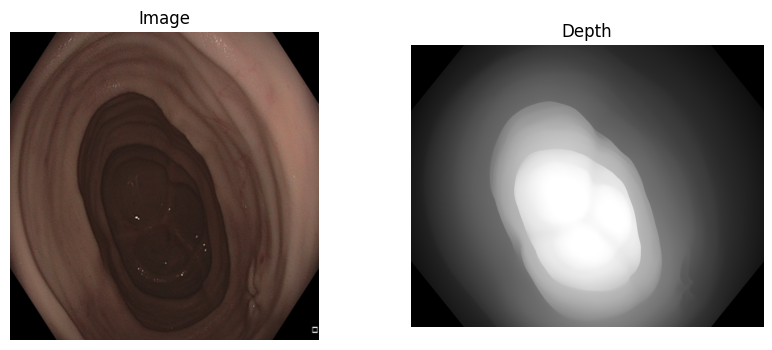

In [60]:
DATA_PATH = "/content/data/cecum_t1_a/cecum_t1_a"

dataset = DepthDataset(DATA_PATH)
import os

import matplotlib.pyplot as plt

img, depth = dataset[0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Depth")
plt.imshow(depth.squeeze(), cmap="gray")
plt.axis("off")

plt.show()

# 5. train val test split

In [61]:
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

print(len(train_set), len(val_set), len(test_set))

193 41 42


# 6. parameter grid

In [62]:
BATCH_SIZE_LIST = [4, 8, 12]
#BATCH_SIZE_LIST = [2]


LEARNING_RATE_LIST = [1e-5, 1e-4, 1e-3]

HYPER_PARAMETER_SET = list(itertools.product(BATCH_SIZE_LIST, LEARNING_RATE_LIST))

# 7. early stopping


In [63]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

# 8 . load GLPN model

In [64]:
# device
device = "cuda" if torch.cuda.is_available() else "cpu"

# processor (only load once)
from transformers import GLPNImageProcessor, GLPNForDepthEstimation
processor = GLPNImageProcessor.from_pretrained("vinvino02/glpn-kitti")

# freeze backbone, train decoder + head

In [65]:
def freeze_backbone_unfreeze_decoder(model):
    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze decoder
    for param in model.decoder.parameters():
        param.requires_grad = True

    # Unfreeze prediction head
    for param in model.head.parameters():
        param.requires_grad = True

    return model

# mini dry run

In [66]:

train_loader = DataLoader(train_set, batch_size=2, shuffle=True)

model = GLPNForDepthEstimation.from_pretrained("vinvino02/glpn-kitti")
model = freeze_backbone_unfreeze_decoder(model).to(device)

imgs, depths = next(iter(train_loader))
imgs = list(imgs)

inputs = processor(images=imgs, return_tensors="pt", do_rescale=False).to(device)
depths = depths.to(device)

outputs = model(**inputs)
preds = outputs.predicted_depth.unsqueeze(1)

print("Pred shape:", preds.shape)
print("Depth shape:", depths.shape)

Loading weights:   0%|          | 0/972 [00:00<?, ?it/s]

Pred shape: torch.Size([2, 1, 384, 384])
Depth shape: torch.Size([2, 1, 1080, 1350])


# 9. training function GLPN

In [67]:
def train_model(model, train_loader, val_loader, lr, epochs=15):
    model = model.to(device)

    train_losses = []
    val_losses = []

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5, min_lr=1e-6
    )

    early_stopping = EarlyStopping(patience=5)

    criterion = nn.L1Loss()

    for epoch in range(epochs):
        # ---------------- TRAIN ----------------
        start_time = time.time() #start timer
        model.train()
        train_loss = 0

        for imgs, depths in train_loader:
            imgs = list(imgs)  # list of PIL images
            depths = depths.to(device).float()
            #normalize depth
            depths = (depths - depths.min()) / (depths.max() - depths.min() + 1e-8)

            inputs = processor(images=imgs, return_tensors="pt").to(device)
            ####
            '''
            outputs = model(**inputs)
            preds = outputs.predicted_depth.unsqueeze(1)

            preds = F.interpolate(
                preds,
                size=depths.shape[-2:],
                mode='bilinear',
                align_corners=False
            )

            loss = criterion(preds, depths)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            '''
            ####
            ####
            optimizer.zero_grad()

            with autocast():
                outputs = model(**inputs)
                preds = outputs.predicted_depth.unsqueeze(1)

                preds = F.interpolate(
                    preds,
                    size=depths.shape[-2:],
                    mode='bilinear',
                    align_corners=False
                )
            #normalize preds
                preds = preds / (preds.max() + 1e-8)
                loss = criterion(preds, depths)

            scaler.scale(loss).backward()

            scaler.step(optimizer)
            scaler.update()

            ####
            #memory change
            train_loss += loss.item()



        # ---------------- VALIDATION ----------------
        model.eval()
        val_loss = 0

        with torch.no_grad(), autocast():
            for imgs, depths in val_loader:
                imgs = list(imgs)
                depths = depths.to(device).float()
                #normalize depth
                depths = (depths - depths.min()) / (depths.max() - depths.min() + 1e-8)

                inputs = processor(images=imgs, return_tensors="pt").to(device)
                outputs = model(**inputs)

                preds = outputs.predicted_depth.unsqueeze(1)
                preds = F.interpolate(
                    preds,
                    size=depths.shape[-2:],
                    mode='bilinear',
                    align_corners=False
                )
                #normalize preds
                preds = preds / (preds.max() + 1e-8)

                loss = criterion(preds, depths)
                val_loss += loss.item()

        # averages
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        scheduler.step(val_loss)
        early_stopping(val_loss)
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch}: Train {train_loss:.4f} | Val {val_loss:.4f} | Time {epoch_time:.2f}s")

        if early_stopping.stop:
            print("Early stopping triggered")
            break

    return model, val_loss, train_losses, val_losses

# 10. hyperparam loop

In [17]:
best_model = None
best_loss = float('inf')
best_config = None

#store training history
history = {}

for batch_size, lr in HYPER_PARAMETER_SET:
    print(f"\nTrying batch={batch_size}, lr={lr}")

    # DataLoaders
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size)

    # Load fresh pretrained model EACH TIME
    model = GLPNForDepthEstimation.from_pretrained("vinvino02/glpn-kitti")

    # Apply freeze strategy
    model = freeze_backbone_unfreeze_decoder(model)

    # (optional debug)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable} / {total} ({100*trainable/total:.2f}%)")

    # Train
    trained_model, val_loss, train_losses, val_losses = train_model(
        model, train_loader, val_loader, lr)

    # store history
    history[(batch_size, lr)] = {
        "train": train_losses,
        "val": val_losses
    }

    # Track best
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = trained_model
        best_config = (batch_size, lr)

print("\nBest config:", best_config)
print("Best validation loss:", best_loss)


Trying batch=4, lr=1e-05


Loading weights:   0%|          | 0/972 [00:00<?, ?it/s]

Trainable params: 378215 / 61220903 (0.62%)


It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.
/tmp/ipykernel_23036/1072796047.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


KeyboardInterrupt: 

# best config of model / save after hyperparam tuning

In [68]:
batch_size, lr = 8, 0.001  # manually plug this

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)

model = GLPNForDepthEstimation.from_pretrained("vinvino02/glpn-kitti")
model = freeze_backbone_unfreeze_decoder(model)

best_model, val_loss, train_losses, val_losses = train_model(
    model, train_loader, val_loader, lr
)

Loading weights:   0%|          | 0/972 [00:00<?, ?it/s]

/tmp/ipykernel_23036/1072796047.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_23036/1072796047.py:84: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), autocast():


Epoch 0: Train 0.1634 | Val 0.1115 | Time 17.57s
Epoch 1: Train 0.0928 | Val 0.1143 | Time 17.50s
Epoch 2: Train 0.0765 | Val 0.1670 | Time 17.76s
Epoch 3: Train 0.0774 | Val 0.0950 | Time 17.39s
Epoch 4: Train 0.0673 | Val 0.1030 | Time 17.64s
Epoch 5: Train 0.0641 | Val 0.0587 | Time 17.57s
Epoch 6: Train 0.0524 | Val 0.0501 | Time 17.46s
Epoch 7: Train 0.0580 | Val 0.0569 | Time 17.49s
Epoch 8: Train 0.0439 | Val 0.0449 | Time 17.68s
Epoch 9: Train 0.0457 | Val 0.0620 | Time 17.57s
Epoch 10: Train 0.0511 | Val 0.0456 | Time 17.51s
Epoch 11: Train 0.0470 | Val 0.0583 | Time 17.57s
Epoch 12: Train 0.0460 | Val 0.0534 | Time 17.55s
Epoch 13: Train 0.0382 | Val 0.0325 | Time 17.50s
Epoch 14: Train 0.0319 | Val 0.0482 | Time 17.51s


In [69]:
torch.save(best_model.state_dict(), "/content/best_model.pth")

In [20]:
model = GLPNForDepthEstimation.from_pretrained("vinvino02/glpn-kitti")
model = freeze_backbone_unfreeze_decoder(model)

model.load_state_dict(torch.load("/content/best_model.pth"))
model = model.to(device)

Loading weights:   0%|          | 0/972 [00:00<?, ?it/s]

# 11. Evaluation


In [21]:
def scale_invariant_loss(pred, target):
    eps = 1e-8
    pred = pred + eps
    target = target + eps

    log_diff = torch.log(pred) - torch.log(target)

    return (log_diff**2).mean() - (log_diff.mean())**2


def evaluate_model(model, test_loader):
    model.eval()
    total_loss = 0

    with torch.no_grad(), torch.amp.autocast("cuda"):
        for imgs, depths in test_loader:
            imgs = list(imgs)
            depths = depths.to(device).float()

            # normalize depth
            depths = (depths - depths.min()) / (depths.max() - depths.min() + 1e-8)

            inputs = processor(images=imgs, return_tensors="pt").to(device)
            outputs = model(**inputs)

            preds = outputs.predicted_depth.unsqueeze(1)
            preds = F.interpolate(preds, size=depths.shape[-2:], mode='bilinear')

            # normalize preds
            preds = preds / (preds.max() + 1e-8)

            loss = scale_invariant_loss(preds, depths)
            total_loss += loss.item()

    return total_loss / len(test_loader)

In [22]:
test_loader = DataLoader(test_set, batch_size=2)
test_loss = evaluate_model(best_model, test_loader)

print("Scale-Invariant Test Loss:", test_loss)

Scale-Invariant Test Loss: 11.196311541966029


# 12. visualize predictions

In [23]:
print(dataset)

In [24]:
import matplotlib.pyplot as plt

def visualize_predictions(model, dataset, num_samples=3):
    model.eval()

    for i in range(num_samples):
        img, depth = dataset[i]

        depth = depth.float()
        depth = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)

        inputs = processor(images=[img], return_tensors="pt").to(device)

        with torch.no_grad(), torch.amp.autocast("cuda"):
            outputs = model(**inputs)

        pred = outputs.predicted_depth.unsqueeze(1)
        pred = F.interpolate(pred, size=depth.shape[-2:], mode='bilinear')
        pred = pred / (pred.max() + 1e-8)

        pred = pred.squeeze().cpu().numpy()
        depth = depth.squeeze().cpu().numpy()

        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.imshow(img)
        plt.title("Input")

        plt.subplot(1,3,2)
        plt.imshow(depth, cmap="gray")
        plt.title("Ground Truth")

        plt.subplot(1,3,3)
        plt.imshow(pred, cmap="gray")
        plt.title("Prediction")

        plt.show()

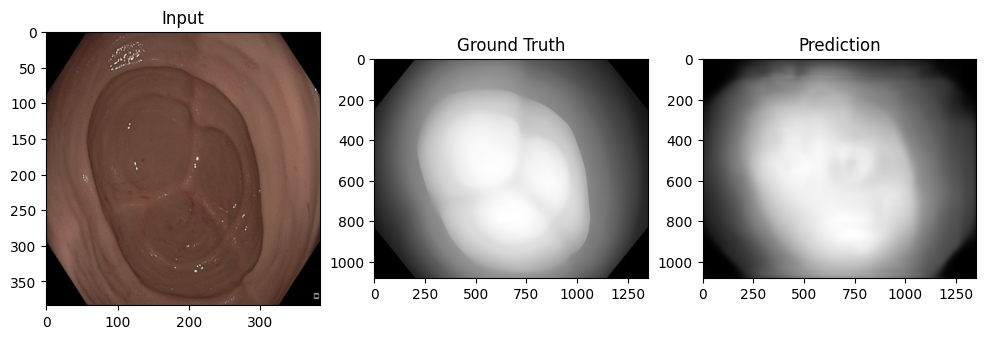

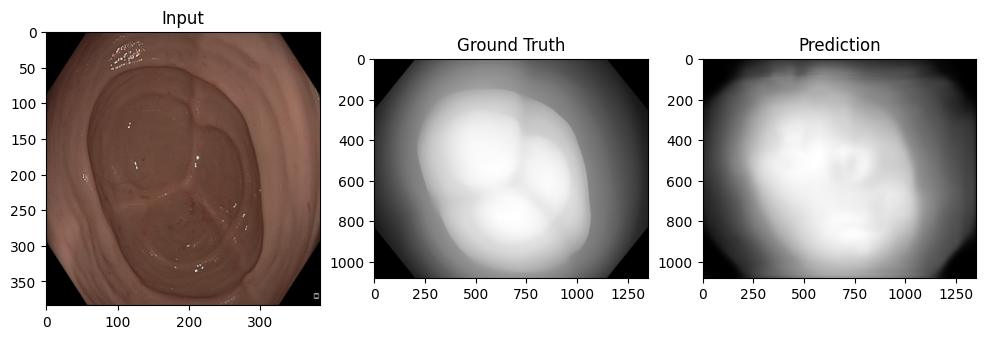

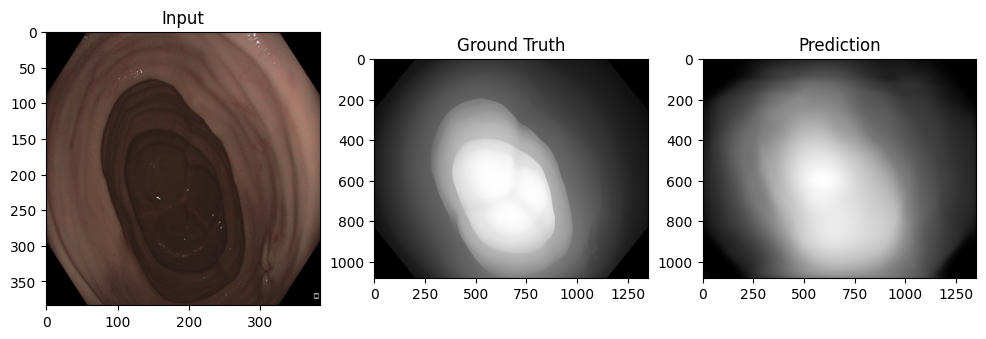

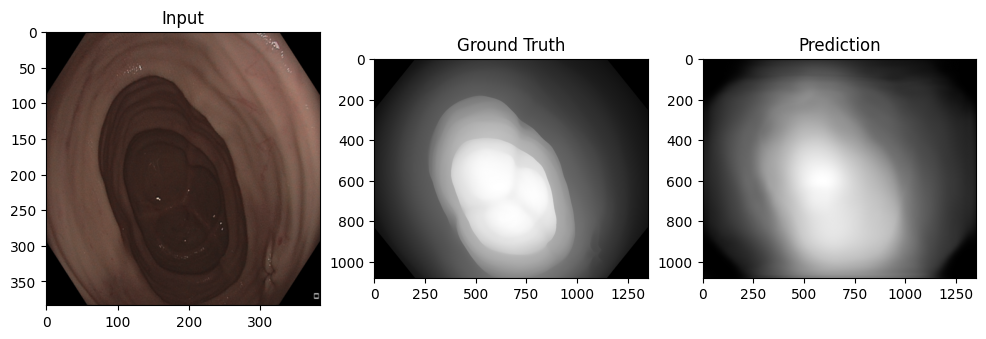

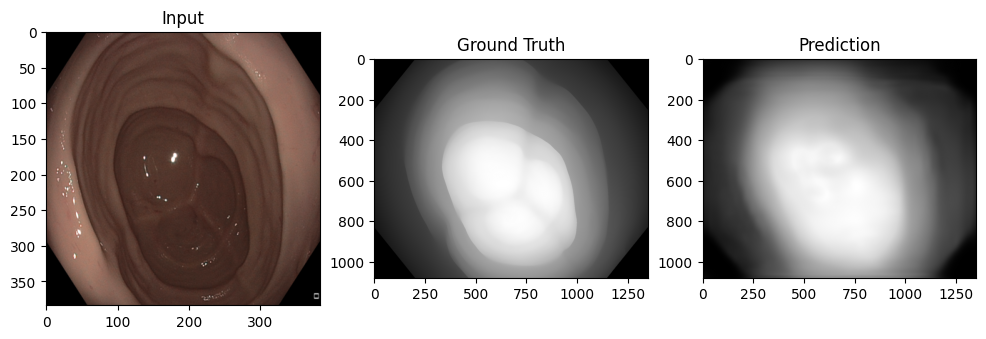

In [ ]:
visualize_predictions(best_model, test_set, num_samples=5)

# 13. compare pre trained and fine tuned

Loading weights:   0%|          | 0/972 [00:00<?, ?it/s]

=== PRETRAINED MODEL ===


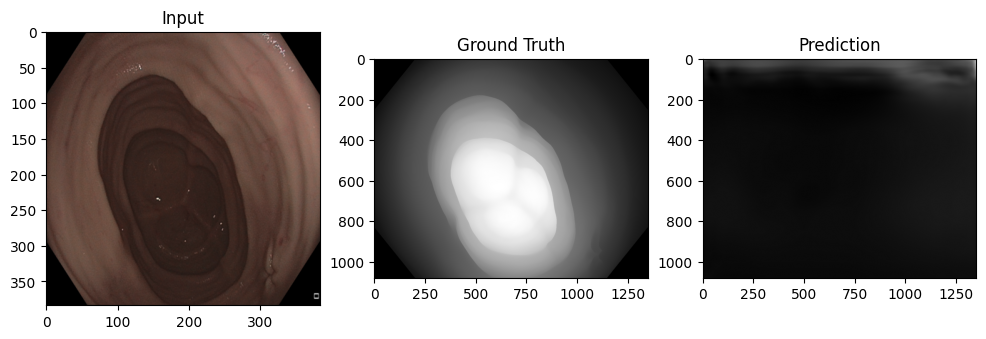

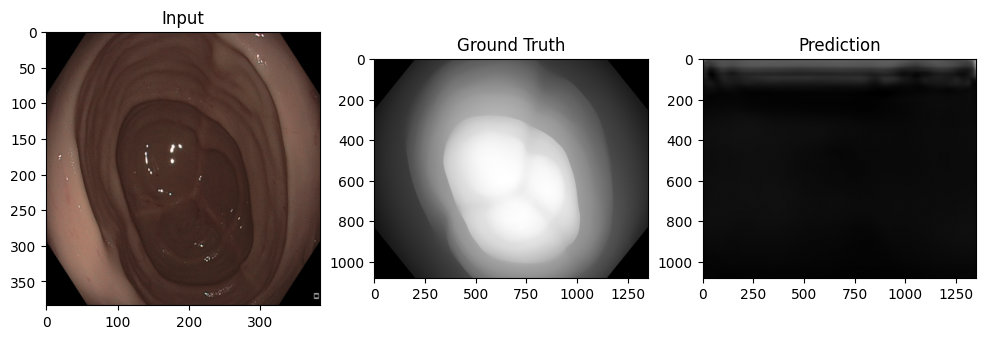

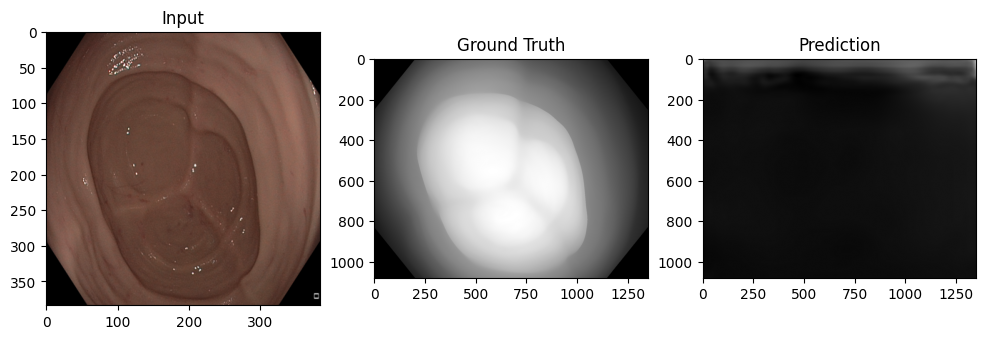

=== FINE-TUNED MODEL ===


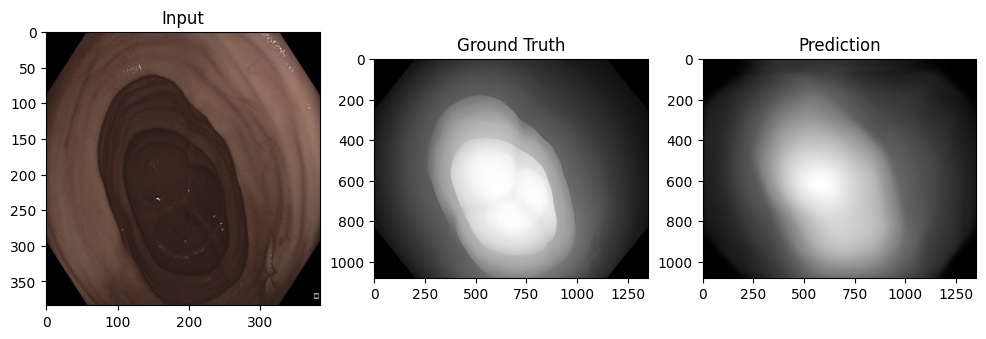

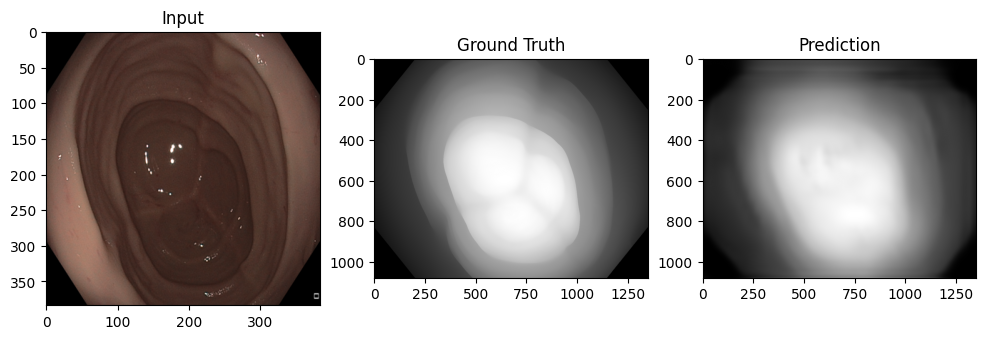

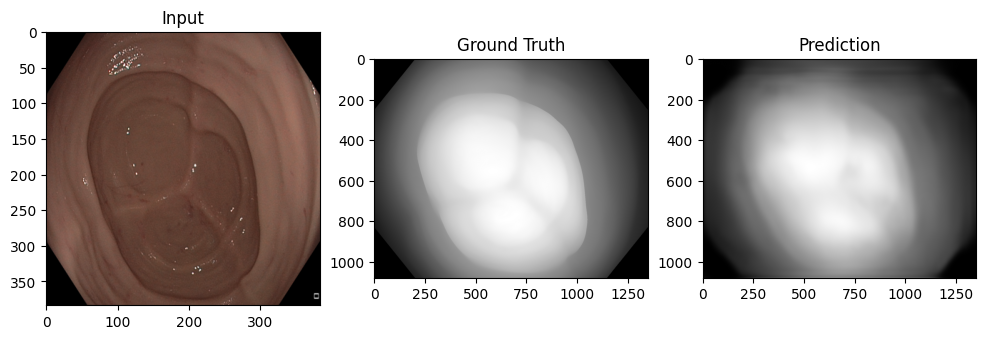

In [25]:
# Load baseline model
baseline_model = GLPNForDepthEstimation.from_pretrained("vinvino02/glpn-kitti").to(device)

print("=== PRETRAINED MODEL ===")
visualize_predictions(baseline_model, test_set, num_samples=3)

print("=== FINE-TUNED MODEL ===")
visualize_predictions(best_model, test_set, num_samples=3)

# 14. plot training curves

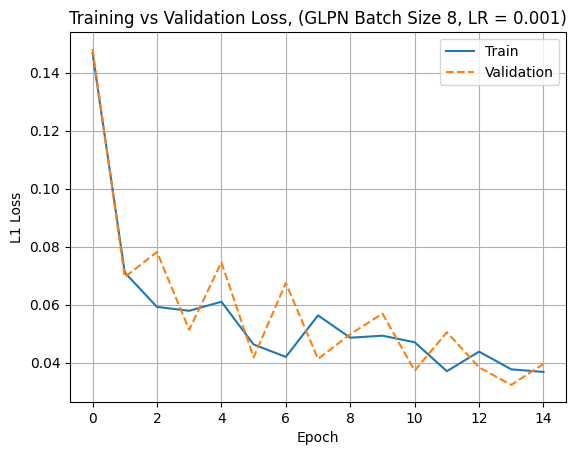

In [31]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(val_losses, linestyle="--", label="Validation")

plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training vs Validation Loss, (GLPN Batch Size 8, LR = 0.001)")
plt.legend()
plt.grid()
plt.show()

# 15. comparison of default vs fine tuned model

In [27]:
def evaluate_si(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad(), torch.amp.autocast("cuda"):
        for imgs, depths in loader:
            imgs = list(imgs)
            depths = depths.to(device).float()

            # normalize depth
            depths = (depths - depths.min()) / (depths.max() - depths.min() + 1e-8)

            inputs = processor(images=imgs, return_tensors="pt").to(device)
            outputs = model(**inputs)

            preds = outputs.predicted_depth.unsqueeze(1)
            preds = F.interpolate(preds, size=depths.shape[-2:], mode='bilinear')

            # normalize preds
            preds = preds / (preds.max() + 1e-8)

            loss = scale_invariant_loss(preds, depths)
            total_loss += loss.item()

    return total_loss / len(loader)

In [37]:
test_loader = DataLoader(test_set, batch_size=8)

# baseline
baseline_model = GLPNForDepthEstimation.from_pretrained("vinvino02/glpn-kitti").to(device)

baseline_loss = evaluate_si(baseline_model, test_loader)
finetuned_loss = evaluate_si(best_model, test_loader)

print("Baseline SI Loss:", baseline_loss)
print("Fine-tuned SI Loss:", finetuned_loss)

Loading weights:   0%|          | 0/972 [00:00<?, ?it/s]

Baseline SI Loss: 20.51060390472412
Fine-tuned SI Loss: 10.993647893269857


In [29]:
improvement = baseline_loss - finetuned_loss

print(f"Baseline: {baseline_loss:.4f}")
print(f"Fine-tuned: {finetuned_loss:.4f}")
print(f"Improvement: {improvement:.4f}")

Baseline: 20.8268
Fine-tuned: 11.1963
Improvement: 9.6305


# Testing on other dataset

In [47]:
os.makedirs("/content/data/images_21", exist_ok=True)

In [48]:
ZIP_PATH = "/content/data/images.zip"
EXTRACT_PATH = "/content/data/images_21"

import zipfile

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

In [49]:

print(os.listdir("/content/data/images_21"))

['image_4_color.tiff', 'image_2_color.tiff', 'image_3_color.tiff', 'image_1_color.tiff']


In [38]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image

def visualize_4_images(base_model, finetuned_model, image_paths):
    baseline_model.eval()
    best_model.eval()

    for path in image_paths[:4]:
        img = Image.open(path).convert("RGB")

        inputs = processor(images=[img], return_tensors="pt").to(device)

        with torch.no_grad(), torch.amp.autocast("cuda"):
            out_base = base_model(**inputs)
            out_ft = finetuned_model(**inputs)

        # get predictions
        pred_base = out_base.predicted_depth.unsqueeze(1)
        pred_ft = out_ft.predicted_depth.unsqueeze(1)

        # resize to input image size
        h, w = img.size[1], img.size[0]
        pred_base = F.interpolate(pred_base, size=(h, w), mode='bilinear')
        pred_ft = F.interpolate(pred_ft, size=(h, w), mode='bilinear')

        # normalize
        pred_base = pred_base / (pred_base.max() + 1e-8)
        pred_ft = pred_ft / (pred_ft.max() + 1e-8)

        pred_base = pred_base.squeeze().cpu().numpy()
        pred_ft = pred_ft.squeeze().cpu().numpy()

        # plot
        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.imshow(img)
        plt.title("Input")

        plt.subplot(1,3,2)
        plt.imshow(pred_base, cmap="gray")
        plt.title("Base Model")

        plt.subplot(1,3,3)
        plt.imshow(pred_ft, cmap="gray")
        plt.title("Fine-tuned")

        plt.show()

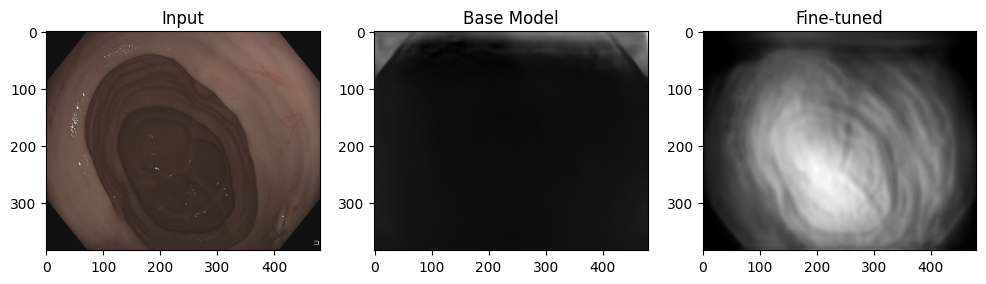

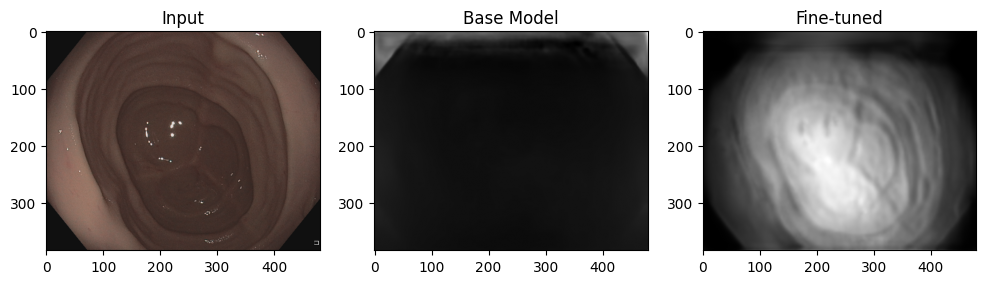

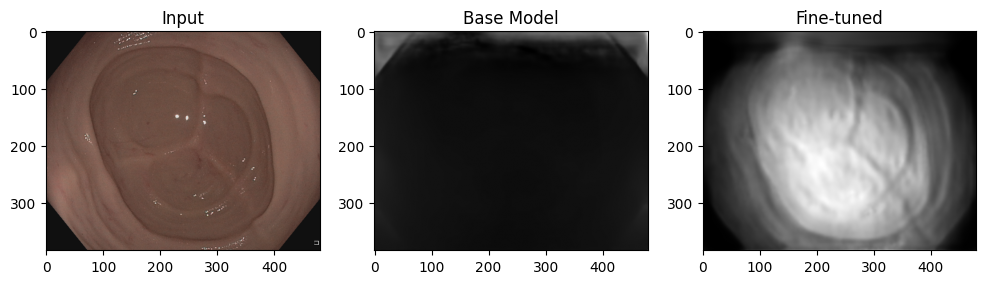

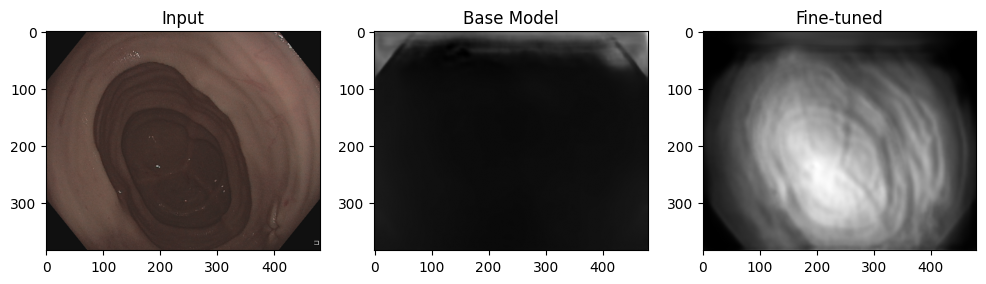

In [40]:
image_paths = [
    "/content/data/images_2/image_1_color.tiff",
    "/content/data/images_2/image_2_color.tiff",
    "/content/data/images_2/image_3_color.tiff",
    "/content/data/images_2/image_4_color.tiff"
]

visualize_4_images(baseline_model, best_model, image_paths)

In [45]:
import os
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image

def save_depth_predictions(base_model, finetuned_model, image_paths):
    base_model.eval()
    finetuned_model.eval()

    def normalize(x):
        x = x - x.min()
        x = x / (x.max() + 1e-8)
        return x

    for idx, path in enumerate(image_paths[:4], start=1):
        img = Image.open(path).convert("RGB")

        inputs = processor(images=[img], return_tensors="pt").to(device)

        with torch.no_grad(), torch.amp.autocast("cuda"):
            out_base = base_model(**inputs)
            out_ft = finetuned_model(**inputs)

        # predictions
        pred_base = out_base.predicted_depth.unsqueeze(1)
        pred_ft = out_ft.predicted_depth.unsqueeze(1)

        # resize to original size
        h, w = img.size[1], img.size[0]
        pred_base = F.interpolate(pred_base, size=(h, w), mode='bilinear')
        pred_ft = F.interpolate(pred_ft, size=(h, w), mode='bilinear')

        # to numpy
        pred_base = pred_base.squeeze().cpu().numpy()
        pred_ft = pred_ft.squeeze().cpu().numpy()

        # normalize properly (fixes black image issue)
        pred_base = normalize(pred_base)
        pred_ft = normalize(pred_ft)

        # save paths
        folder = "/content/data/images_3/"
        base_path = os.path.join(folder, f"image_base_{idx}.tiff")
        ft_path = os.path.join(folder, f"image_best_{idx}.tiff")

        # save as FLOAT32 TIFF (preserves depth + avoids black images)
        Image.fromarray(pred_base.astype(np.float32)).save(base_path)
        Image.fromarray(pred_ft.astype(np.float32)).save(ft_path)

        print(f"Saved: {base_path}, {ft_path}")

In [ ]:
image_paths = [
    "/content/data/images_2/image_1_color.tiff",
    "/content/data/images_2/image_2_color.tiff",
    "/content/data/images_2/image_3_color.tiff",
    "/content/data/images_2/image_4_color.tiff"
]

save_depth_predictions(baseline_model, best_model, image_paths)